# Import Libraries

In [1]:
import torch
from torch_geometric.data import Batch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Load in Trained Models

In [2]:
from Models import CustomGNN  

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Model Weights
model_configs = {
    'ergodic': {
        'path': 'trained_models/best_ergodic_gnn.pth',
        'in_features': 12,
        'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16]
    },
    'partially_nonergodic': {
        'path': 'trained_models/best_partial_gnn.pth',
        'in_features': 14,
        'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16]
    },
    'nonergodic': {
        'path': 'trained_models/best_Nonergodic_gnn.pth',
        'in_features': 17,
        'indices': None
    } 
}

#Store models in a dictionary
loaded_models = {}

for model_name, config in model_configs.items():
    
    model = CustomGNN(
        in_features=config['in_features'], 
        hidden_channels=64, 
        out_channels=6, 
        pos_dim=2,
        indices_to_keep=config['indices']
    )
    
    model.load_state_dict(torch.load(config['path'], map_location=device))
    model.to(device)
    model.eval() 
    
    loaded_models[model_name] = model

print(f"Successfully loaded: {list(loaded_models.keys())}")

Successfully loaded: ['ergodic', 'partially_nonergodic', 'nonergodic']


# Load in Data

In [3]:
from metadata import example_metadata, periods_to_plot

plotting_examples = torch.load('earthquake_examples/plotting_examples.pth')

print("Successfully loaded: plotting examples, period information, earthquake metadata")

Successfully loaded: plotting examples, period information, earthquake metadata


# Make a Prediction

=== Model Prediction Setup ===
Available models: ['ergodic', 'partially_nonergodic', 'nonergodic']


Type the name of the model you want to use:  partially_nonergodic



Available examples:
  [0] S. San Andreas: M6.55, Depth = 6.8km
  [1] Newport Inglewood Connected alt 2: M6.75, Depth = 1.1km
  [2] Elsinore;GI+T: M6.95, Depth = 3.3km 
  [3] San Jacinto;SJV: M7.25, Depth = 3.5km
  [4] San Jacinto;SBV+SJV+A+CC+B: M7.55, Depth = 10.8km
  [5] Elsinore;W+GI+T+J: M7.55, Depth = 4.5km
  [6] Elsinore: M7.65, Depth = 1.5km
  [7] Newport Inglewood Connected alt 1: M7.75, Depth = 3.1km
  [8] S. San Andreas;NM+SM+NSB+SSB+BG: M7.95, Depth = 3.2km
  [9] S. San Andreas;PK+CH+CC+BB+NM+SM+NSB: M8.25, Depth = 1.7km



Type the number (0-9) of the example you want to visualize:  8



Available periods (s): [2.0, 3.0, 4.0, 5.0, 7.5, 10.0]


Type the period you want to plot:  10.0

Would you like to save this figure as a PNG? (y/n):  n



Generating plot for Model: PARTIALLY_NONERGODIC | Example: 8 | Period: 10.0s...


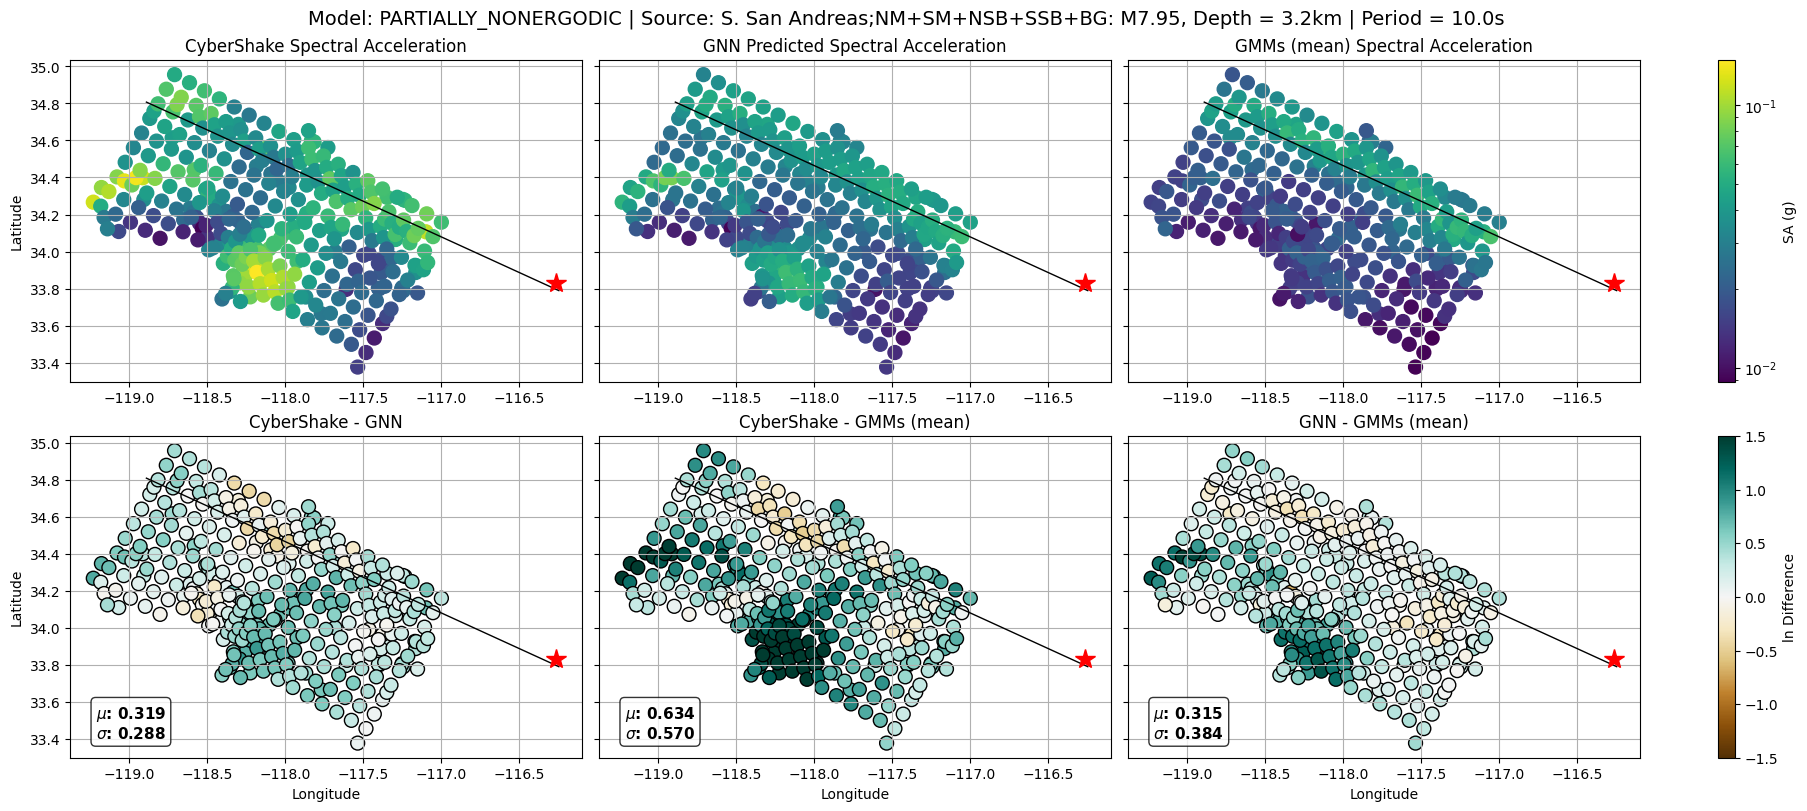

In [4]:
#Run this cell to make a prediction

from plotting import run_prediction_prompt

run_prediction_prompt(
    loaded_models=loaded_models, 
    plotting_examples=plotting_examples, 
    example_metadata=example_metadata, 
    periods_to_plot=periods_to_plot, 
    device=device
)